In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data
df = pd.read_csv("data\diabetes\diabetic_data.csv")
ids = pd.read_csv("data\diabetes\IDS_mapping.csv")

# Basic cleaning
#df = df.replace("?", np.nan)

In [3]:
# Binary target: readmitted within 30 days
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)


In [4]:
# Helpful labels for admission type
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped"
}

In [5]:
df["admission_type"] = df["admission_type_id"].map(admission_type_map)

# Quick overview
print("Shape:", df.shape)
print("\nReadmission target distribution:")
print(df["readmitted"].value_counts(dropna=False))

print("\n30-day readmission rate:")
print(df["readmitted_30"].mean())

Shape: (101766, 52)

Readmission target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

30-day readmission rate:
0.11159915885462728


## Readmission rates by race

In [6]:
race_rates = (
    df.groupby("race")["readmitted_30"]
    .agg(
        total_patients="count",
        readmitted_patients="sum",
        readmission_rate="mean"
    )
    .sort_values("readmission_rate", ascending=False)
)

# Convert to percentage
race_rates["readmission_rate_%"] = race_rates["readmission_rate"] * 100

race_rates

,total_patients,readmitted_patients,readmission_rate,readmission_rate_%
race,,,,
Caucasian,76099,8592,0.112906,11.290556
AfricanAmerican,19210,2155,0.112181,11.218116
Hispanic,2037,212,0.104075,10.407462
Asian,641,65,0.101404,10.140406
Other,1506,145,0.096282,9.628154
?,2273,188,0.082710,8.271007


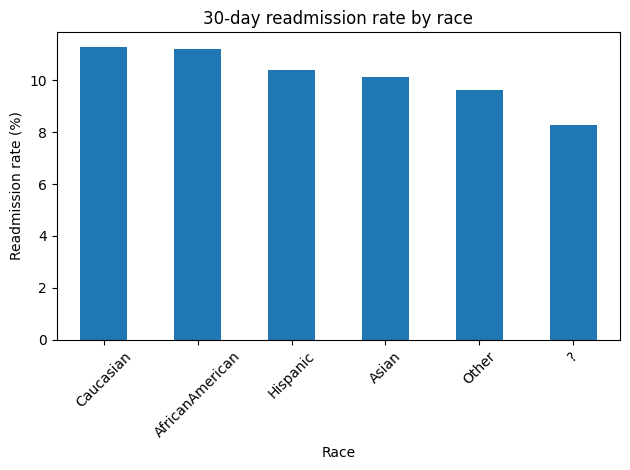

In [7]:
race_rates["readmission_rate_%"].plot(kind="bar")
plt.title("30-day readmission rate by race")
plt.ylabel("Readmission rate (%)")
plt.xlabel("Race")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Gender comparison

In [8]:
gender_rates = (
    df.groupby("gender")["readmitted_30"]
    .agg(
        total_patients="count",
        readmitted_patients="sum",
        readmission_rate="mean"
    )
    .sort_values("readmission_rate", ascending=False)
)

# Convert to percentage
gender_rates["readmission_rate_%"] = gender_rates["readmission_rate"] * 100

gender_rates

,total_patients,readmitted_patients,readmission_rate,readmission_rate_%
gender,,,,
Female,54708,6152,0.112452,11.245156
Male,47055,5205,0.110615,11.061524
Unknown/Invalid,3,0,0.000000,0.000000


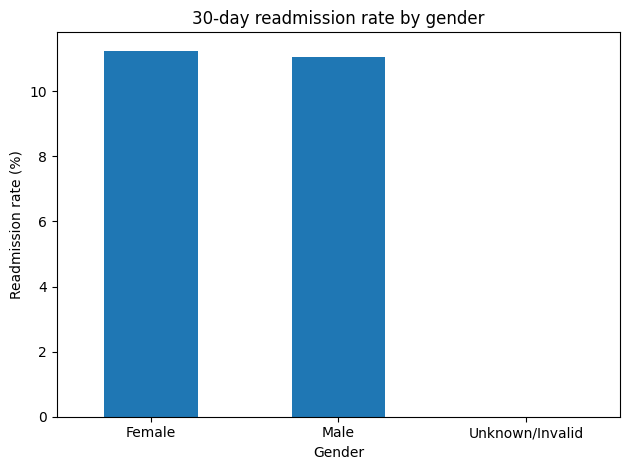

In [9]:
gender_rates["readmission_rate_%"].plot(kind="bar")
plt.title("30-day readmission rate by gender")
plt.ylabel("Readmission rate (%)")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Readmission rates by admission type

In [10]:
admission_rates = (
    df.groupby("admission_type")["readmitted_30"]
    .agg(
        total_patients="count",
        readmitted_patients="sum",
        readmission_rate="mean"
    )
    .sort_values("readmission_rate", ascending=False)
)

# Convert to percentage
admission_rates["readmission_rate_%"] = admission_rates["readmission_rate"] * 100

admission_rates

,total_patients,readmitted_patients,readmission_rate,readmission_rate_%
admission_type,,,,
Emergency,53990,6221,0.115225,11.522504
Urgent,18480,2066,0.111797,11.179654
NULL,5291,586,0.110754,11.075411
Elective,18869,1961,0.103927,10.392708
Not Available,4785,495,0.103448,10.344828
Newborn,10,1,0.100000,10.000000
Not Mapped,320,27,0.084375,8.437500
Trauma Center,21,0,0.000000,0.000000


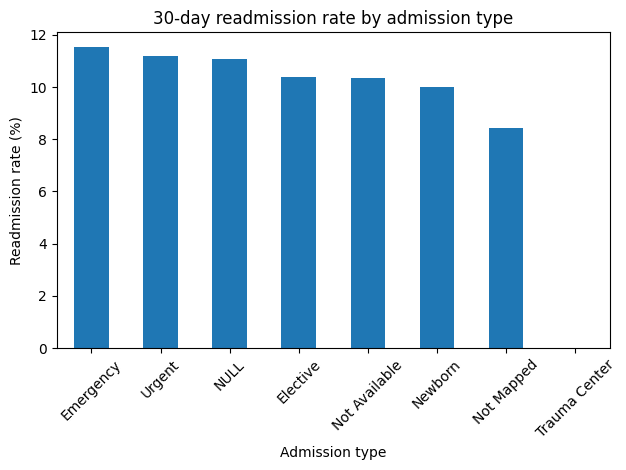

In [11]:
admission_rates["readmission_rate_%"].plot(kind="bar")
plt.title("30-day readmission rate by admission type")
plt.ylabel("Readmission rate (%)")
plt.xlabel("Admission type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Prior inpatient visits vs readmission

In [12]:
# How many times a patient was previously admitted as an inpatient
inpatient_rates = (
    df.groupby("number_inpatient")["readmitted_30"]
    .agg(["count", "mean"])
    .sort_index()
)

inpatient_rates["readmission_rate_%"] = inpatient_rates["mean"] * 100
inpatient_rates.head(15)

,count,mean,readmission_rate_%
number_inpatient,,,
0,67630,0.084371,8.437084
1,19521,0.129245,12.924543
2,7566,0.174333,17.433254
3,3411,0.202873,20.287306
4,1622,0.236128,23.612824
5,812,0.314039,31.403941
6,480,0.345833,34.583333
7,268,0.354478,35.447761
8,151,0.443709,44.370861


The more prior inpatient visits, the higher the readmission risk

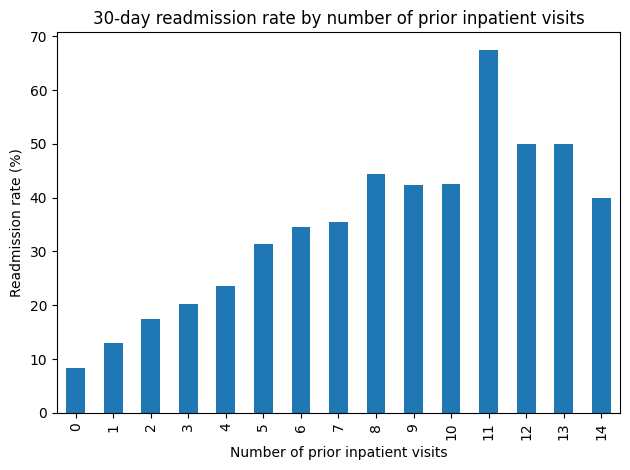

In [13]:
inpatient_rates["readmission_rate_%"].head(15).plot(kind="bar")
plt.title("30-day readmission rate by number of prior inpatient visits")
plt.ylabel("Readmission rate (%)")
plt.xlabel("Number of prior inpatient visits")
plt.tight_layout()
plt.show()